# geeViz Google Maps Platform Examples

This notebook demonstrates `geeViz.googleMapsLib` — 24 functions for ground-truthing remote sensing analysis using Google Maps Platform APIs.

**Requirements:**
- `pip install geeViz`
- A `.env` file in the geeViz directory with:
  ```
  GEMINI_API_KEY=your_key_here
  GOOGLE_MAPS_PLATFORM_API_KEY=your_key_here
  ```
- For segmentation: `pip install geeViz[segmentation]`

| Section | APIs Used |
|---|---|
| 1. Geocoding | Geocoding, Reverse Geocoding, Address Validation |
| 2. Street View | Street View Static, Panorama Stitching |
| 3. Places | Places (New), Place Photos |
| 4. Environment | Elevation, Air Quality, Solar, Timezone |
| 5. AI Analysis | Gemini Interpretation, Object Detection |
| 6. Segmentation | SegFormer Semantic Segmentation |


[![github](https://img.shields.io/badge/-see%20sources-white?logo=github&labelColor=555)](https://github.com/gee-community/geeviz/blob/master/examples/googleMapsLib_examples.ipynb) 
[![github](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gee-community/geeViz/blob/master/examples/googleMapsLib_examples.ipynb)

In [2]:
import geeViz.googleMapsLib as gm
from IPython.display import display, HTML, Image as IPImage, Markdown
import json, os, time

output_dir = os.path.join(os.path.dirname(os.getcwd()), "examples", "outputs", "google_maps")
os.makedirs(output_dir, exist_ok=True)
print(f"Output: {output_dir}")
print(f"Maps key: {'set' if gm._get_api_key() else 'MISSING'}")

Output: c:\RCR\geeVizBuilder\geeViz\examples\outputs\google_maps
Maps key: set


---
## 1. Geocoding

Convert addresses to coordinates and back.

In [7]:
# Forward geocode
loc = gm.geocode("100 S State St, Salt Lake City, UT")
print(f"Address: {loc['formatted_address']}")
print(f"Coords: {loc['lat']}, {loc['lon']}")
print(f"Accuracy: {loc['location_type']}")

# Reverse geocode
rev = gm.reverse_geocode(loc['lon'], loc['lat'])
print(f"\nReverse: {rev['formatted_address']}")

# Address validation
val = gm.validate_address("3000 asdf way slc ut")
if val:
    print(f"\nValidated: {val['formatted_address']}")
    print(f"Complete: {val['verdict']['address_complete']}")
    if val.get('usps_data'):
        print(f"USPS: {val['usps_data']['standardized_address'].get('firstAddressLine')}")

Address: State St & 100 S, Salt Lake City, UT 84138, USA
Coords: 40.7671365, -111.888139
Accuracy: GEOMETRIC_CENTER

Reverse: 95 S State St Suite 900, Salt Lake City, UT 84111, USA

Validated: 3000 asdf way, Salt Lake City, UT, USA
Complete: False
USPS: 3000 ASDF WAY


---
## 2. Street View

Fetch Street View imagery — single frames, cardinal directions, stitched panoramas.

Status: OK, Date: 2025-08


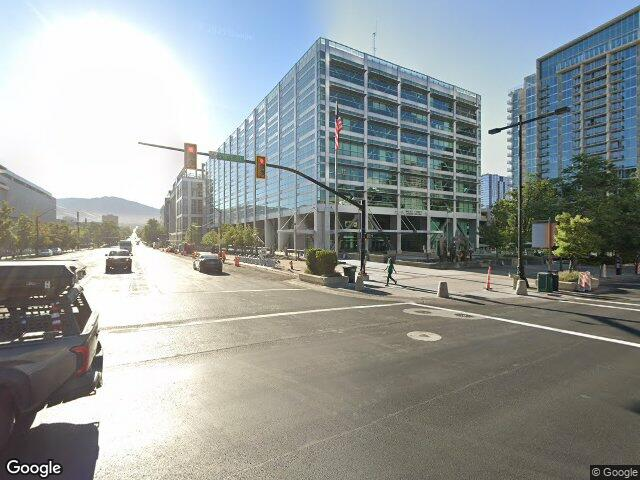

Single frame: 61,565 bytes


In [8]:
# Check coverage
meta = gm.streetview_metadata(loc['lon'], loc['lat'])
print(f"Status: {meta['status']}, Date: {meta.get('date')}")

# Single image
img = gm.streetview_image(loc['lon'], loc['lat'], heading=120)
if img:
    display(IPImage(data=img, width=600))
    print(f"Single frame: {len(img):,} bytes")

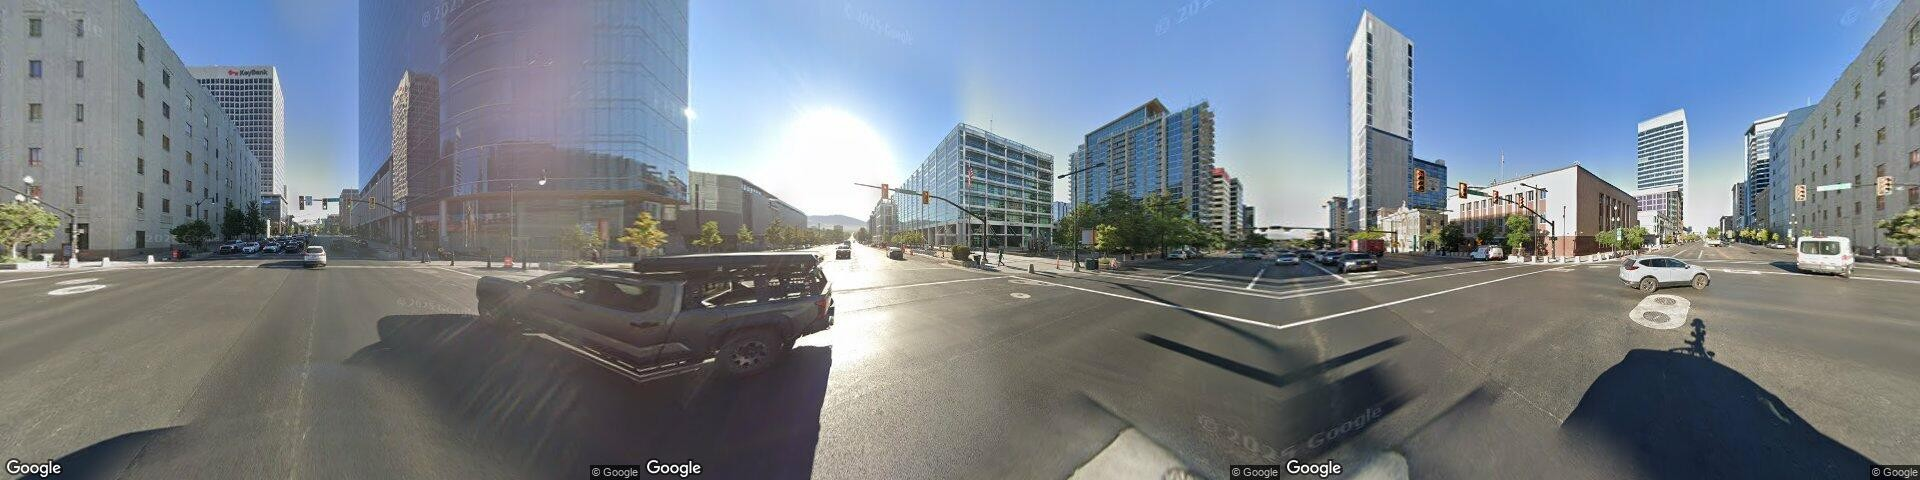

360° panorama: 194,109 bytes


In [9]:
# 360° stitched panorama
pano = gm.streetview_panorama(loc['lon'], loc['lat'], heading=120, fov=360)
if pano:
    display(IPImage(data=pano, width=900))
    print(f"360° panorama: {len(pano):,} bytes")


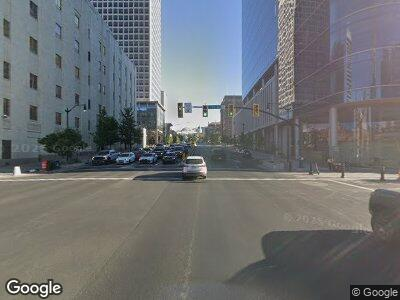
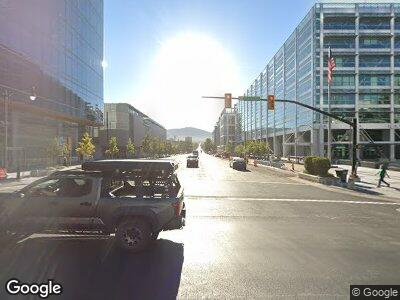
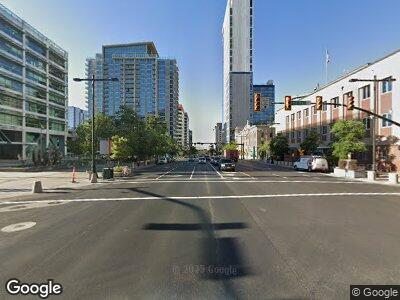
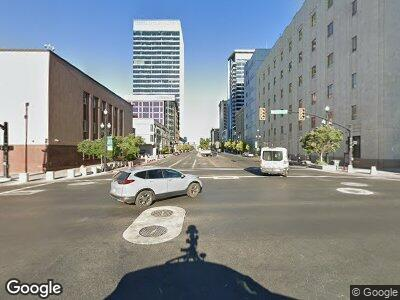

In [10]:
# HTML panel with cardinal directions
html = gm.streetview_html(loc['lon'], loc['lat'])
if html:
    display(HTML(html))

---
## 3. Places

Search for places near a location.

In [11]:
# Text search
places = gm.search_places("coffee shop", lat=loc['lat'], lon=loc['lon'], radius=2000)
print(f"Found {len(places)} coffee shops:\n")
for p in places[:5]:
    rating = f" ({p['rating']}★)" if p.get('rating') else ""
    print(f"  {p['display_name']}{rating}: {p['address']}")

# Nearby search
parks = gm.search_nearby(loc['lat'], loc['lon'], radius=3000, included_types=["park"])
print(f"\nFound {len(parks)} parks nearby")
for p in parks[:3]:
    print(f"  {p['display_name']}: {p['address']}")

Found 10 coffee shops:

  JJ Coffee Co (4.8★): 330 E 400 S Ste 102, Salt Lake City, UT 84111, USA
  Buzzed Coffeehouse (4.9★): 265 S State St Ste 113, Salt Lake City, UT 84111, USA
  The People's Coffee (4.6★): 177 E 200 S, Salt Lake City, UT 84111, USA
  Three Pines Coffee (4.5★): 165 S Main St, Salt Lake City, UT 84111, USA
  District Coffee Co. (4.6★): 206 N 200 W #1, Salt Lake City, UT 84103, USA

Found 10 parks nearby
  Liberty Park: 600 Harvey Milk Blvd, Salt Lake City, UT 84105, USA
  Capitol Hill, Salt Lake City, UT: Utah State Capitol, Salt Lake City, UT 84103, USA
  Pioneer Park: 350 S 300 W, Salt Lake City, UT 84101, USA


---
## 4. Environment

Elevation, air quality, solar potential, and timezone.

In [12]:
# Elevation
elev = gm.get_elevation(loc['lon'], loc['lat'])
print(f"Elevation: {elev:.0f} m ({elev * 3.28084:.0f} ft)")

# Elevation profile
profile = gm.get_elevation_along_path(
    [(-111.89, 40.77), (-111.80, 40.68)],  # SLC downtown to Wasatch foothills
    samples=10,
)
print(f"\nElevation profile ({len(profile)} points):")
for p in profile:
    print(f"  ({p['lat']:.4f}, {p['lon']:.4f}): {p['elevation']:.0f} m")

Elevation: 1315 m (4313 ft)

Elevation profile (10 points):
  (40.7700, -111.8900): 1324 m
  (40.7600, -111.8800): 1304 m
  (40.7500, -111.8700): 1306 m
  (40.7400, -111.8600): 1322 m
  (40.7300, -111.8500): 1354 m
  (40.7200, -111.8400): 1370 m
  (40.7100, -111.8300): 1387 m
  (40.7000, -111.8200): 1411 m
  (40.6900, -111.8100): 1456 m
  (40.6800, -111.8000): 1503 m


AQI: 70 — Good air quality
Dominant pollutant: pm10

Solar potential:
  Max panels: 476
  Annual output: 272,665 kWh
  Roof area: 1387 m²


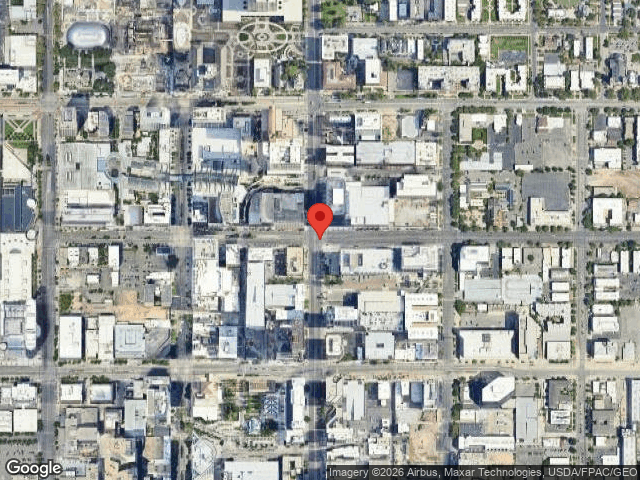


Timezone: America/Denver (Mountain Daylight Time)


In [13]:
# Air quality
aq = gm.get_air_quality(loc['lon'], loc['lat'])
if aq:
    print(f"AQI: {aq['aqi']} — {aq['category']}")
    print(f"Dominant pollutant: {aq['dominant_pollutant']}")

# Solar potential
solar = gm.get_solar_insights(loc['lon'], loc['lat'])
if solar:
    print(f"\nSolar potential:")
    print(f"  Max panels: {solar['max_panels']}")
    print(f"  Annual output: {solar['max_annual_kwh']:,.0f} kWh")
    print(f"  Roof area: {solar['roof_area_m2']:.0f} m²")
# Show static map of the location
static_map = gm.get_static_map(loc['lon'], loc['lat'],zoom=16,markers=[(loc['lon'],loc['lat'])])
if static_map:
    display(IPImage(data=static_map, width=600))

# Timezone
tz = gm.get_timezone(loc['lon'], loc['lat'])
if tz:
    print(f"\nTimezone: {tz['timezone_id']} ({tz['timezone_name']})")

---
## 5. AI Analysis (Gemini)

Use Gemini to interpret and label Street View imagery. Requires `GEMINI_API_KEY`.

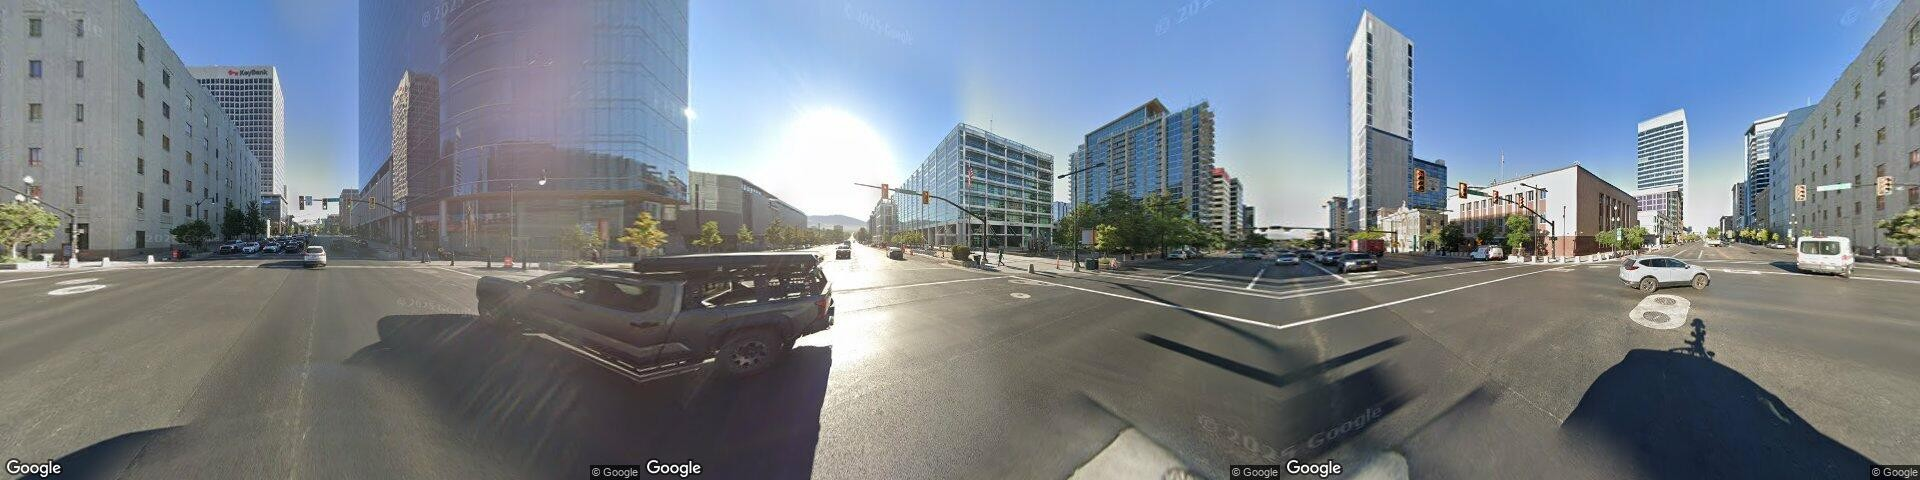

Intpretting image...
Finished intpretting image


This image depicts a bustling downtown intersection in Salt Lake City, characterized by a mix of modern glass skyscrapers and older stone-faced commercial buildings. The landscape is dominated by wide asphalt roads and concrete sidewalks, with sparse vegetation limited to small street trees lining the thoroughfares. Notable infrastructure includes multiple traffic signals, streetlights, and a variety of vehicles navigating the urban grid under a clear, bright sky.



*   **Impervious surface**: 75% (Includes asphalt roads, concrete sidewalks, and building rooftops/facades)
*   **Vegetation**: 2% (Limited to the canopy of small street trees)
*   **Bare soil**: 0% (No exposed earth is visible in this dense urban environment)
*   **Sky**: 23% (Clear blue sky visible above the city skyline)

| Object | Count | Notes |
| :--- | :--- | :--- |
| Modern glass skyscraper | 3 | Large buildings with glass facades, including one with a curved front. |
| Stone/concrete office building | 2 | Older, multi-story buildings with traditional masonry or concrete exteriors. |
| Brick commercial building | 1 | A mid-rise brick structure located on the right side of the intersection. |
| Distant high-rise building | 6 | Various tall structures visible in the background skyline, including the KeyBank building. |
| Pickup truck | 1 | Dark grey truck with a roof rack in the immediate foreground. |
| SUV | 1 | White vehicle positioned on the right side of the road. |
| Van | 1 | White commercial-style van on the far right. |
| Passenger car | 15+ | Various cars visible at a distance in traffic across multiple lanes. |
| Street tree | ~28 | Small deciduous trees planted in sidewalk cutouts or planters. |
| Traffic light pole | 6 | Metal poles supporting signal heads at the intersection. |
| Street light pole | ~15 | Tall poles for street illumination along the sidewalks. |
| Street sign | ~8 | Includes street name signs and traffic regulation signs. |
| Crosswalk | 4 | Painted pedestrian crossings at the main intersection. |
| Sidewalk | 4+ | Concrete pedestrian paths bordering the roadways. |

In [14]:
display(IPImage(data=pano, width=900))
print('Intpretting image...')
# Interpret a panorama
result = gm.interpret_image(
    pano,
    context=f"{loc['formatted_address']}. Downtown Salt Lake City.",
)
print('Finished intpretting image')

display(Markdown(result['description']))
display(Markdown(result['object_counts']))

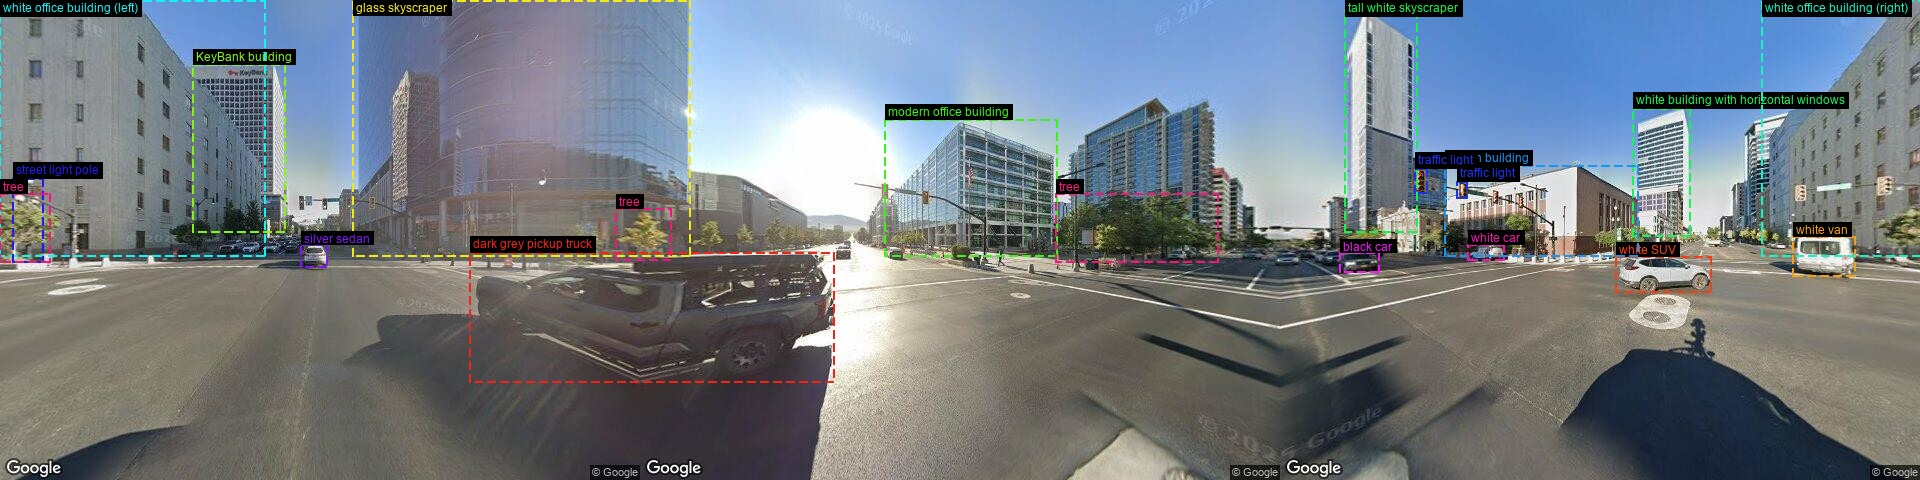

Detected 20 objects


| # | Object | Box |
|---|---|---|
| 1 | dark grey pickup truck | (470,252,833,382) |
| 2 | white SUV | (1616,256,1710,292) |
| 3 | white van | (1793,236,1854,276) |
| 4 | glass skyscraper | (353,0,689,256) |
| 5 | KeyBank building | (193,64,284,232) |
| 6 | modern office building | (885,119,1056,256) |
| 7 | tall white skyscraper | (1345,10,1416,232) |
| 8 | white building with horizontal windows | (1633,108,1689,236) |
| 9 | white office building (right) | (1762,0,1920,256) |
| 10 | white office building (left) | (0,0,264,256) |
| 11 | brown building | (1445,165,1637,256) |
| 12 | traffic light | (1415,168,1426,193) |
| 13 | traffic light | (1457,181,1466,198) |
| 14 | street light pole | (13,178,42,262) |
| 15 | silver sedan | (301,244,326,267) |
| 16 | black car | (1340,252,1378,272) |
| 17 | white car | (1468,244,1503,260) |
| 18 | tree | (0,193,49,262) |
| 19 | tree | (1056,193,1217,262) |
| 20 | tree | (616,208,670,260) |

In [15]:
# Label objects with bounding boxes
labeled = gm.label_streetview(
    loc['lon'], loc['lat'],
    heading=120, fov=360,
    max_labels=20,
)
if labeled:
    display(IPImage(data=labeled['image'], width=900))
    print(f"Detected {len(labeled['detections'])} objects")
    display(Markdown(labeled['summary']))

---
## 6. Semantic Segmentation (SegFormer)

Pixel-level land cover classification. Requires `pip install geeViz[segmentation]`.

The image processor of type `SegformerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

Segmented in 51.7s


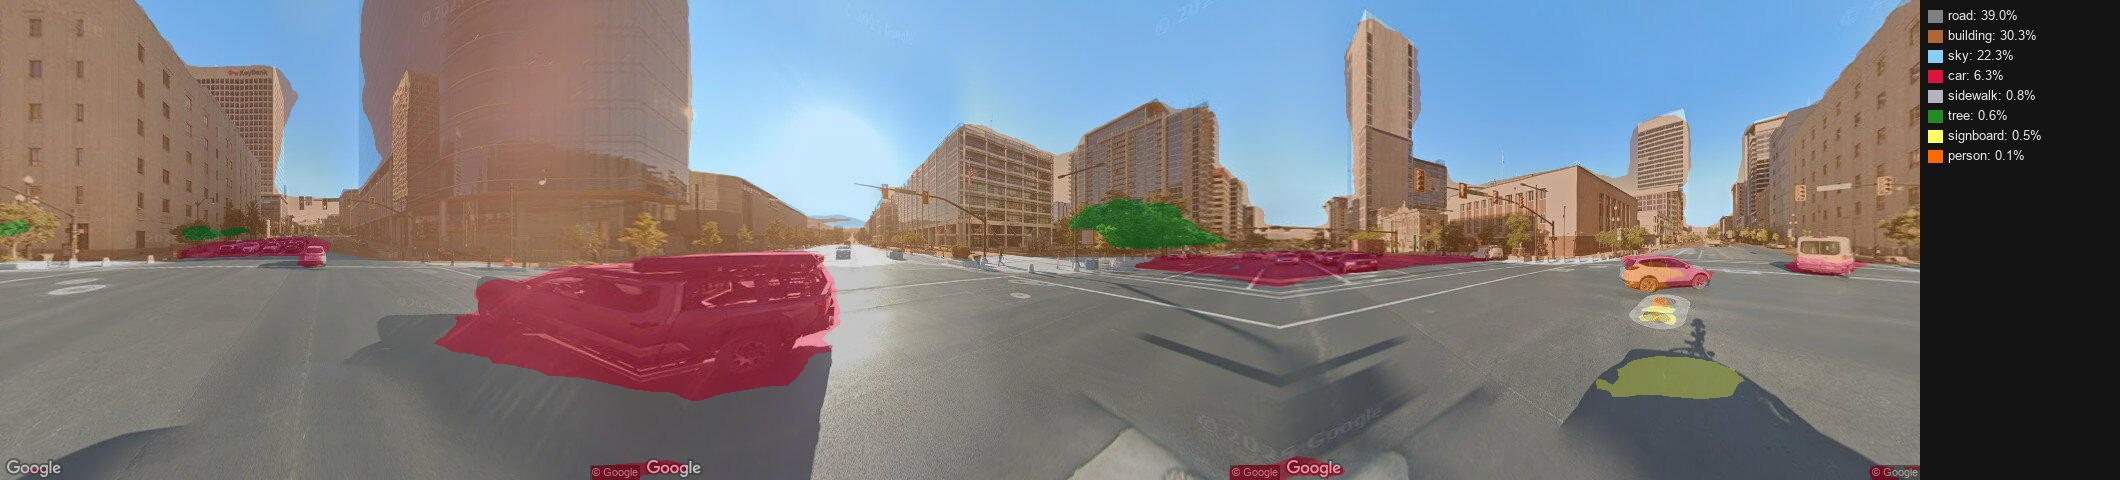

| Category | Area (%) |
|---|---|
| road | 39.0% |
| building | 30.3% |
| sky | 22.3% |
| car | 6.3% |
| sidewalk | 0.8% |
| tree | 0.6% |
| signboard | 0.5% |
| person | 0.1% |

In [16]:
# Segment the panorama with SegFormer B4
try:
    t0 = time.time()
    seg = gm.segment_image(pano, model_variant="b4", broad_categories=False)
    print(f"Segmented in {time.time()-t0:.1f}s")
    display(IPImage(data=seg['colored_image'], width=900))
    display(Markdown(seg['summary']))
except ImportError:
    print("SegFormer requires: pip install geeViz[segmentation]")

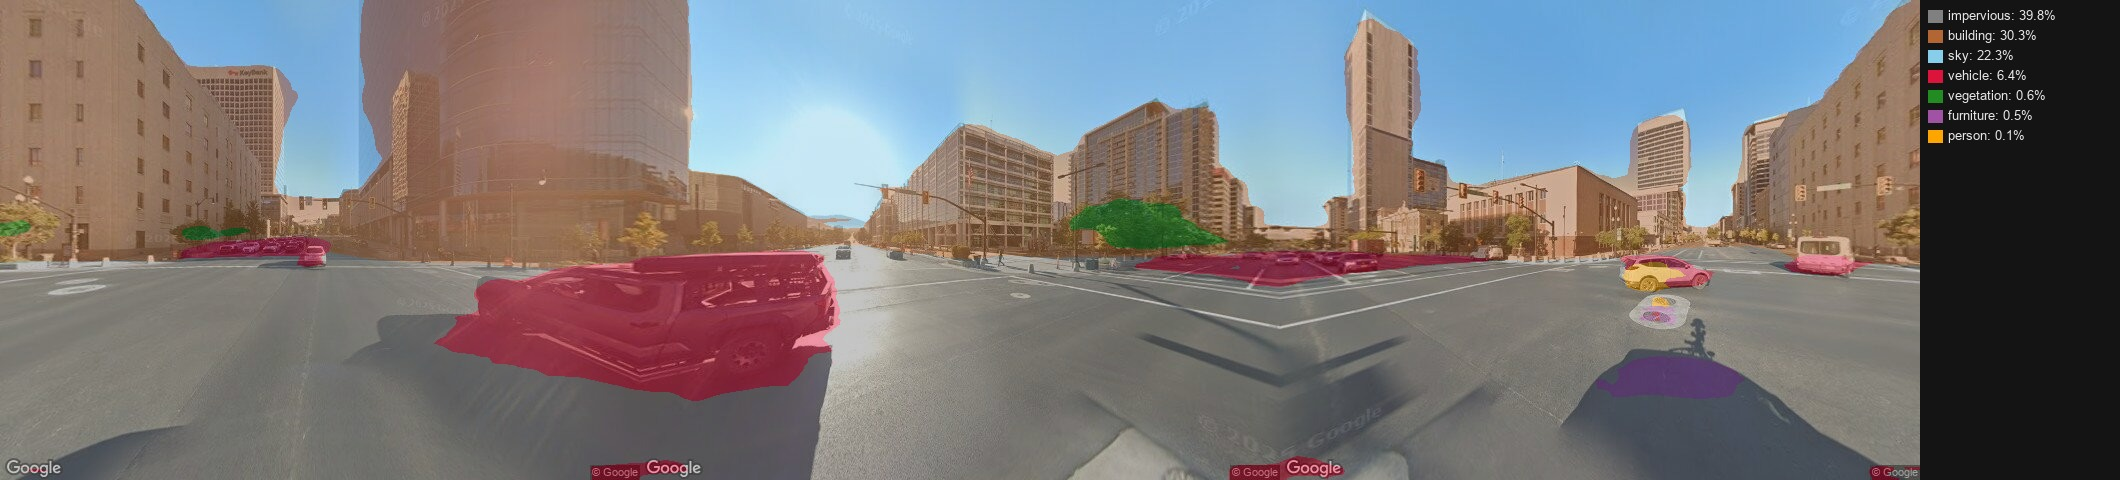

| Category | Area (%) |
|---|---|
| impervious | 39.8% |
| building | 30.3% |
| sky | 22.3% |
| vehicle | 6.4% |
| vegetation | 0.6% |
| furniture | 0.5% |
| person | 0.1% |

In [17]:
# Segment with broad land cover categories
try:
    seg_broad = gm.segment_image(pano, model_variant="b4", broad_categories=True)
    display(IPImage(data=seg_broad['colored_image'], width=900))
    display(Markdown(seg_broad['summary']))
except ImportError:
    print("SegFormer requires: pip install geeViz[segmentation]")

---
## 7. Roads & Static Maps

Nearest roads: 1 segments
  (40.76714, -111.88814)


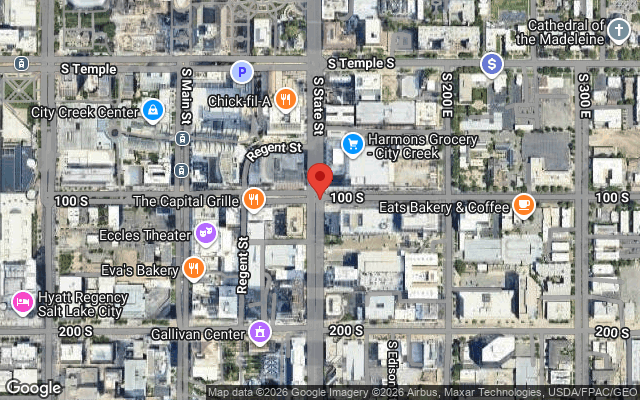

Static map: 189,316 bytes


In [18]:
# Nearest roads
roads = gm.nearest_roads(loc['lon'], loc['lat'])
print(f"Nearest roads: {len(roads)} segments")
for r in roads:
    print(f"  ({r['lat']:.5f}, {r['lon']:.5f})")

# Static map
static = gm.get_static_map(
    loc['lon'], loc['lat'],
    zoom=16, size="640x400", maptype="hybrid",
    markers=[(loc['lon'], loc['lat'])],
)
if static:
    display(IPImage(data=static, width=640))
    print(f"Static map: {len(static):,} bytes")

---
## Summary

| Category | Functions | API Key |
|---|---|---|
| Geocoding | `geocode`, `reverse_geocode`, `validate_address` | `GOOGLE_MAPS_PLATFORM_API_KEY` |
| Places | `search_places`, `search_nearby`, `get_place_photo` | `GOOGLE_MAPS_PLATFORM_API_KEY` |
| Street View | `streetview_metadata`, `streetview_image`, `streetview_panorama`, `streetview_html` | `GOOGLE_MAPS_PLATFORM_API_KEY` |
| AI Analysis | `interpret_image`, `label_streetview` | `GEMINI_API_KEY` |
| Segmentation | `segment_image`, `segment_streetview` | None (local model) |
| Elevation | `get_elevation`, `get_elevations`, `get_elevation_along_path` | `GOOGLE_MAPS_PLATFORM_API_KEY` |
| Environment | `get_air_quality`, `get_solar_insights`, `get_timezone` | `GOOGLE_MAPS_PLATFORM_API_KEY` |
| Maps & Roads | `get_static_map`, `snap_to_roads`, `nearest_roads` | `GOOGLE_MAPS_PLATFORM_API_KEY` |